# FASE 3: IA Explicable (XAI)

## Preparación del entorno

In [45]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt

In [46]:
shap.initjs

<function shap.plots._force.initjs()>

In [47]:
modelo_xgb = joblib.load('../models/modelo_xgb.pkl')
X_test_scaled = pd.read_csv('../data/X_test_scaled.csv')
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer(X_test_scaled)

In [65]:
scaler = joblib.load('../models/scaler.pkl')
X_test_r=scaler.inverse_transform(X_test_scaled)
X_test_df = pd.DataFrame(X_test_r, columns=X_test_scaled.columns).round(0).astype(int)


## Valores SHAP globales

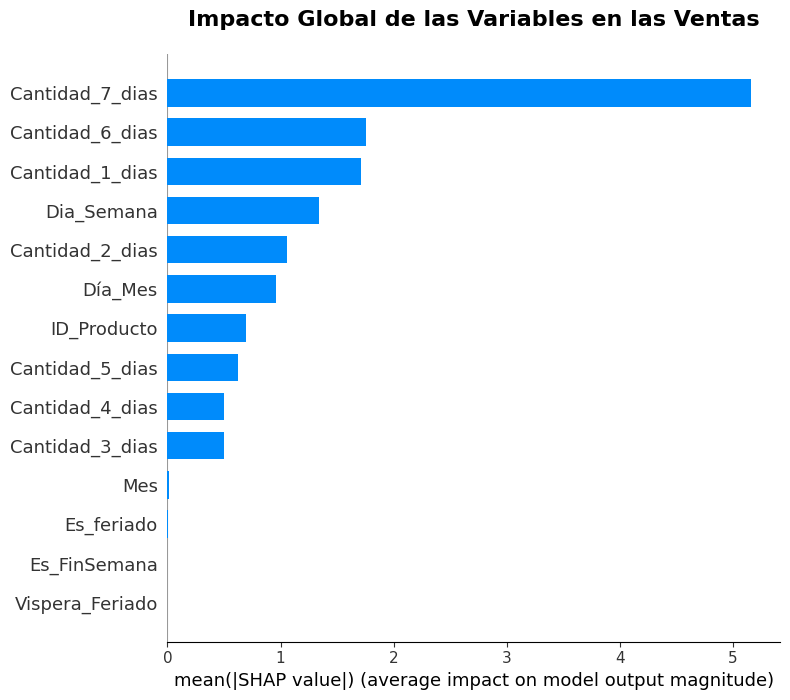

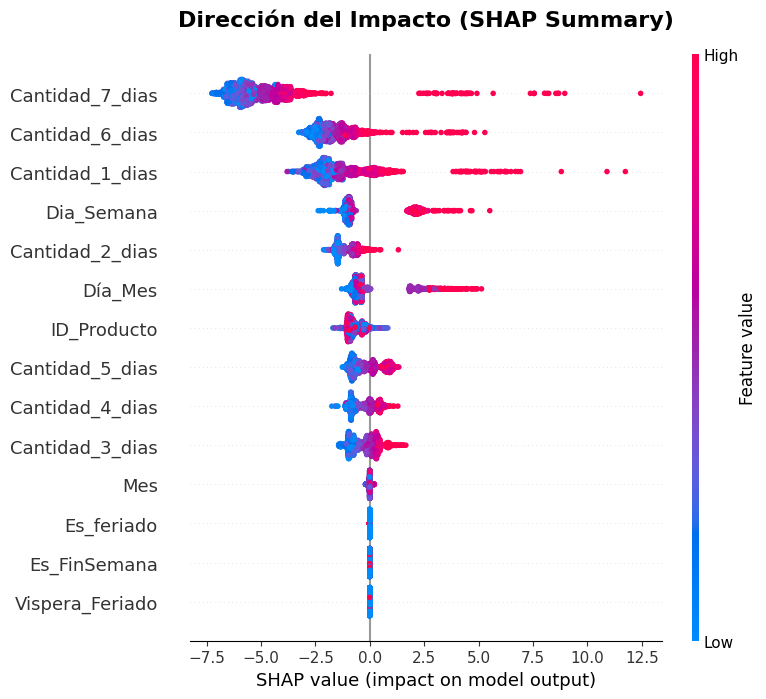

In [48]:
# Gráfico de Importancia Global (Resumen de Impacto)
plt.figure(figsize=(10, 6))
plt.title("Impacto Global de las Variables en las Ventas", fontsize=16, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# Gráfico de Abeja (Muestra direcciones: ¿Un valor alto en 'Es_FinSemana' sube o baja la venta?)
plt.figure(figsize=(10, 6))
plt.title("Dirección del Impacto (SHAP Summary)", fontsize=16, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.show()

## Función para extraer analisis para el LLM

In [62]:
def explicar_prediccion_negocio(id_producto, mes=None, dia_semana=None):
    """
    Busca un escenario en el Test Set. Si no lo encuentra, guía al usuario 
    mostrando qué datos sí están disponibles para ese producto.
    """
    #Filtar por ID de Producto
    filtro_producto = (X_test_df['ID_Producto'] == id_producto)
    df_producto = X_test_df[filtro_producto]
    
    #Validar ID en conjunto test
    if df_producto.empty:
        productos_disponibles = sorted(X_test_df['ID_Producto'].unique().tolist())
        print(f"El Producto ID {id_producto} no se encuentra dentro del conjunto de testing")
        print(f"IDs disponibles dentro del conjunto de testing:\n{productos_disponibles}")
        return

    # aplicar filtros de fecha de ser necesario
    condicion = filtro_producto
    if mes is not None:
        condicion = condicion & (X_test_df['Mes'] == mes)
    if dia_semana is not None:
        condicion = condicion & (X_test_df['Dia_Semana'] == dia_semana)
        
    resultados = X_test_df[condicion]
    
    # Validar combinacion de ID + fecha en el conjunto test
    if resultados.empty:
        meses_disp = sorted(df_producto['Mes'].unique().tolist())
        dias_disp = sorted(df_producto['Dia_Semana'].unique().tolist())
        print(f"No se encontró esa comnbinación de fecha + Producto {id_producto}.")
        print(f"Para este producto puedes evaluar:")
        print(f"   - Meses disponibles: {meses_disp}")
        print(f"   - Días de la semana disponibles: {dias_disp}")
        return
        
    # Tomar el primer índice que cumpla la condición
    indice_prediccion = resultados.index[0]
    
    #Construir la explicación local
    explicacion_local = shap.Explanation(
        values = shap_values[indice_prediccion].values,       
        base_values = shap_values[indice_prediccion].base_values, 
        data = X_test_df.iloc[indice_prediccion].values, 
        feature_names = X_test_df.columns.tolist()            
    )
    
    #Generar y mostrar la Gráfica Waterfall
    shap.plots.waterfall(explicacion_local, max_display=10)
    
    # 8. Preparar el texto para el LLM automáticamente
    valor_base = explicacion_local.base_values
    prediccion_final = explicacion_local.values.sum() + valor_base
    
    impactos_local = pd.DataFrame({
        'Variable': X_test_df.columns, 
        'Valor_Original': explicacion_local.data,
        'Impacto_en_Unidades_SHAP': explicacion_local.values
    })
    
    impactos_local['Magnitud_Absoluta'] = impactos_local['Impacto_en_Unidades_SHAP'].abs()
    top_3 = impactos_local.sort_values(by='Magnitud_Absoluta', ascending=False).head(3)
    
    print("\n--- Prompt para LLM ---")
    print("-" * 65)
    print(f"Actúa como un analista de ventas senior. Nuestro modelo XGBoost ha pronosticado una demanda de {prediccion_final:.0f} unidades para el producto ID {id_producto}.")
    print("Matemáticamente, las 3 variables que más impulsaron esta decisión específica fueron:")
    
    contador = 1
    for _, fila in top_3.iterrows():
        print(f" {contador}. '{fila['Variable']}' con un valor actual de {fila['Valor_Original']:.0f}, impactando la predicción en {fila['Impacto_en_Unidades_SHAP']:.2f} unidades.")
        contador += 1
        
    print("Redacta una breve justificación de negocio (máximo 5 líneas) explicando a la gerencia por qué se espera este nivel de ventas para este día específico, omitiendo jerga técnica o menciones a SHAP.")
    print("-" * 65)

## Ejemplos 

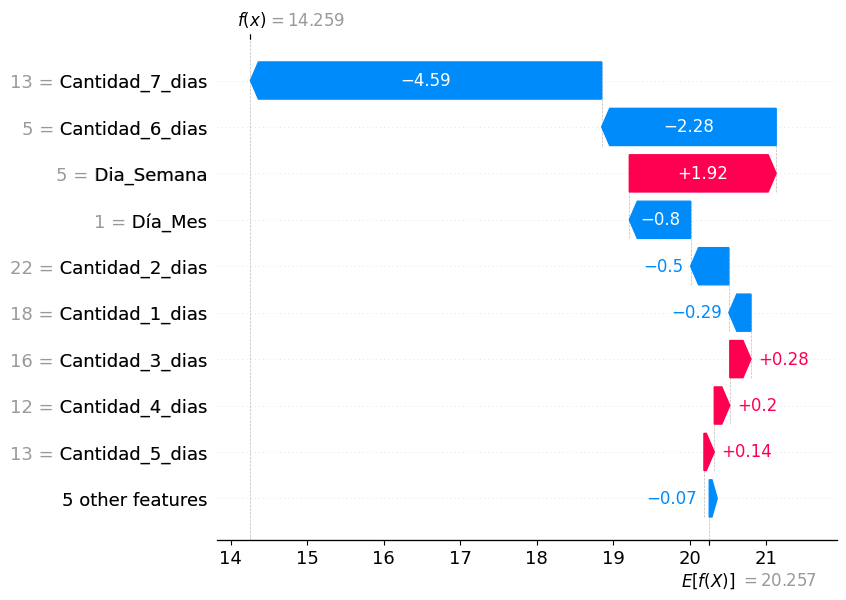


--- Prompt para LLM ---
-----------------------------------------------------------------
Actúa como un analista de ventas senior. Nuestro modelo XGBoost ha pronosticado una demanda de 14 unidades para el producto ID 35.
Matemáticamente, las 3 variables que más impulsaron esta decisión específica fueron:
 1. 'Cantidad_7_dias' con un valor actual de 13, impactando la predicción en -4.59 unidades.
 2. 'Cantidad_6_dias' con un valor actual de 5, impactando la predicción en -2.28 unidades.
 3. 'Dia_Semana' con un valor actual de 5, impactando la predicción en 1.92 unidades.
Redacta una breve justificación de negocio (máximo 5 líneas) explicando a la gerencia por qué se espera este nivel de ventas para este día específico, omitiendo jerga técnica o menciones a SHAP.
-----------------------------------------------------------------


In [ ]:
"""
El conjunto de testing tiene 2493 registros (0 a 2492)
Los IDS disponibles en el conjunto: [31, 32, 33, 34, 35, 36, 37, 38]
No todas las combinaciones de fecha + producto están disponibles en el conjunto de testing.
Esto se debe a que, en series temporales no se pueden separar datos aleatorios, por lo que se tomo el 20% de los datos para test, tomando los ultimos registros según los IDs de producto
Los argumentos mes y dia_semana son opcionales.
"""
explicar_prediccion_negocio(id_producto=35, mes=6, dia_semana=5)

- Respuesta obtenida del LLM ("LLM ESCOGIDO")